# 🏦 Loan Default Prediction | ML Classification

> **Beginner-Friendly Guide** | Binary Classification | SMOTE + LightGBM

---

## 📌 What This Notebook Covers
- **Goal**: Predict whether a loan applicant will **default** (1) or **not default** (0)
- **Dataset**: 45,000 loan records with 13 features (age, income, credit score, etc.)
- **Approach**: Clean data → Explore patterns → Handle class imbalance → Train 4 ML models → Compare results

## 🗂️ Table of Contents
1. Import Libraries  
2. Load & Explore Dataset  
3. Data Cleaning  
4. Exploratory Data Analysis (EDA)  
5. Preprocessing  
6. Handle Class Imbalance (SMOTE)  
7. Model Training & Evaluation  
8. Model Comparison  
9. Best Model – Deep Dive  
10. Conclusion


## 1. 📦 Import Libraries

We start by importing all the Python libraries we need:
- **pandas / numpy**: for data handling and math
- **matplotlib / seaborn**: for beautiful charts
- **sklearn**: for machine learning models and tools
- **imblearn (SMOTE)**: to fix the class imbalance problem
- **xgboost / lightgbm**: powerful boosting algorithms


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. 📂 Load & Explore Dataset

In [ ]:
df = pd.read_csv('loan_data_new.csv')
print("Shape:", df.shape)
print()
print(df.dtypes)

Shape: (45000, 14)

Age                      int64
Gender                     str
Education                  str
Person Income            int64
Employee Experience      int64
Home Onwership             str
Loan Amount              int64
Loan Intent                str
Loan interest Rate     float64
Loan percentage        float64
Credit History           int64
Credit Score             int64
Previous Loan              str
Loan Status              int64
dtype: object


In [ ]:
df.head()

[First 5 rows displayed]


In [ ]:
print("Missing Values:")
print(df.isnull().sum())
print()
print("Target Distribution:")
vc = df['Loan Status'].value_counts()
print(f"  Approved  (0): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)")
print(f"  Defaulted (1): {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)")

Missing Values:
Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Onwership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64

Target Distribution:
  Approved  (0): 35,000  (77.8%)
  Defaulted (1): 10,000  (22.2%)


## 3. 🧹 Data Cleaning

We handle **outliers** — extreme values that don't make sense (e.g. Age = 144).


In [ ]:
# Age outlier: cap at 80
print(f"Before: Max Age = {df['Age'].max()}")
df['Age'] = df['Age'].clip(upper=80)
print(f"After : Max Age = {df['Age'].max()}")

# Income outlier: cap at 99th percentile
income_cap = df['Person Income'].quantile(0.99)
df['Person Income'] = df['Person Income'].clip(upper=income_cap)
print(f"Income capped at 99th percentile: {income_cap:,.0f}")
print("Data cleaning complete!")

Before: Max Age = 144
After : Max Age = 80
Income capped at 99th percentile: 250,000
Data cleaning complete!


## 4. 📊 Exploratory Data Analysis (EDA)

### 4.1 Loan Status Distribution & Credit Score


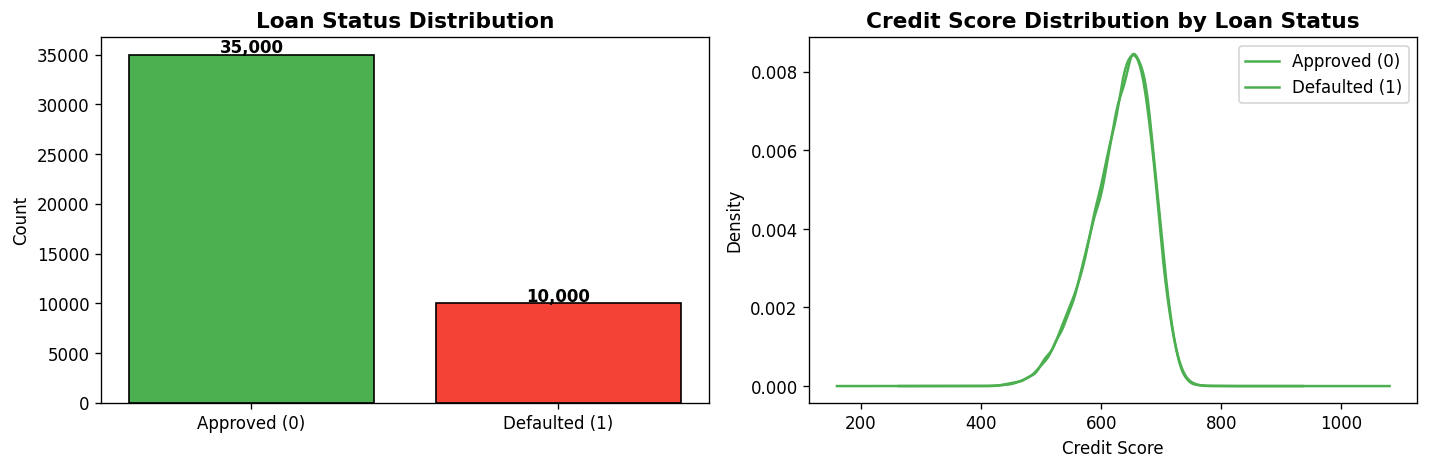

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4CAF50', '#F44336']

val = df['Loan Status'].value_counts()
axes[0].bar(['Approved (0)', 'Defaulted (1)'], val.values, color=colors, edgecolor='black')
axes[0].set_title('Loan Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(val.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

df[df['Loan Status']==0]['Credit Score'].plot(kind='kde', ax=axes[1],
    color='#4CAF50', label='Approved (0)')
df[df['Loan Status']==1]['Credit Score'].plot(kind='kde', ax=axes[1],
    color='#F44336', label='Defaulted (1)')
axes[1].set_title('Credit Score by Loan Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Credit Score')
axes[1].legend()

plt.tight_layout()
plt.show()

**Key Insight**: Dataset is imbalanced (77.8% vs 22.2%). Lower credit scores are linked to default.

### 4.2 Default Rate by Categorical Features


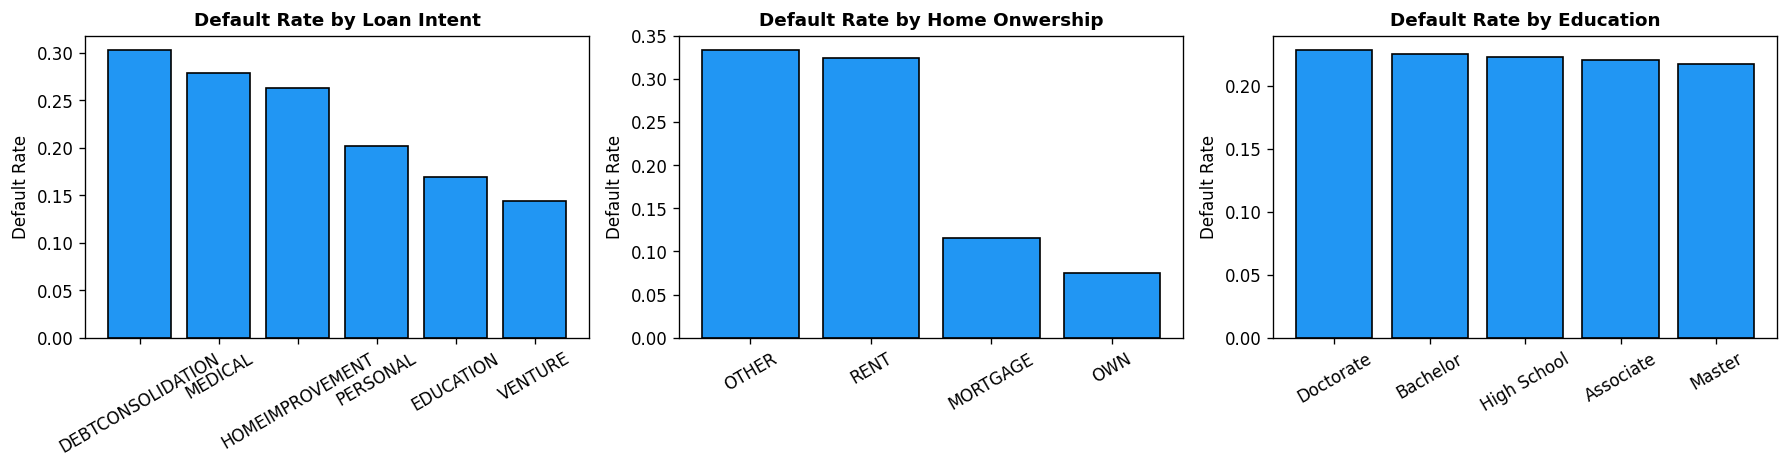

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cats = ['Loan Intent', 'Home Onwership', 'Education']
for i, col in enumerate(cats):
    ct = df.groupby(col)['Loan Status'].mean().sort_values(ascending=False)
    axes[i].bar(ct.index, ct.values, color='#2196F3', edgecolor='black')
    axes[i].set_title(f'Default Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Default Rate')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 4.3 Correlation Heatmap

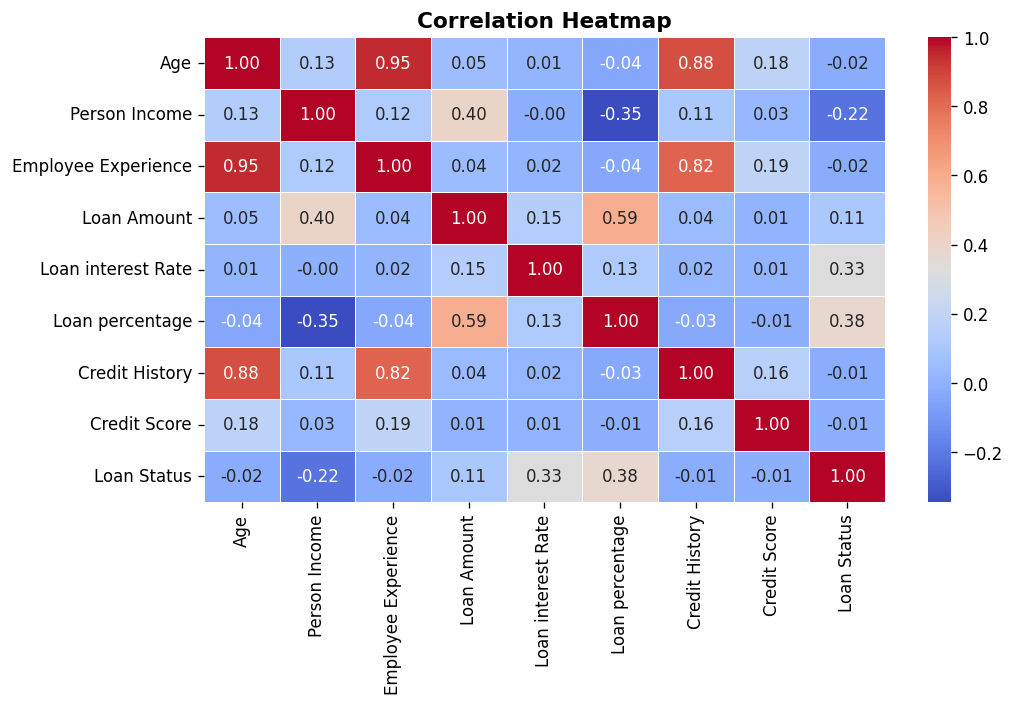

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. ⚙️ Preprocessing

ML models need **numbers only**. We:
1. **Encode** text columns → numbers using `LabelEncoder`
2. **Split** data: 80% train / 20% test
3. **Scale** features for Logistic Regression


In [ ]:
# Encode categorical columns
le = LabelEncoder()
df_enc = df.copy()
cat_cols = df_enc.select_dtypes(include='object').columns.tolist()
print("Columns encoded:", cat_cols)

for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

# Features and target
X = df_enc.drop('Loan Status', axis=1)
y = df_enc['Loan Status']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Columns encoded: ['Gender', 'Education', 'Home Onwership', 'Loan Intent', 'Previous Loan']
Train: 36,000 rows | Test: 9,000 rows


## 6. ⚖️ Handle Class Imbalance with SMOTE

**Problem**: 78% approved vs 22% defaulted — models get biased.  
**Solution**: SMOTE creates *synthetic* samples for the minority class to balance the training data.

> SMOTE is only applied to **training data**. Test data stays original for honest evaluation.


In [ ]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("BEFORE SMOTE:")
print(f"  Approved  (0): {(y_train == 0).sum():,}")
print(f"  Defaulted (1): {(y_train == 1).sum():,}")
print()
print("AFTER SMOTE:")
vc = pd.Series(y_res).value_counts()
print(f"  Approved  (0): {vc[0]:,}")
print(f"  Defaulted (1): {vc[1]:,}")

# Scale the SMOTE data too
X_res_sc = scaler.fit_transform(X_res)
print("\nReady for training!")

BEFORE SMOTE:
  Approved  (0): 28,000
  Defaulted (1): 8,000

AFTER SMOTE:
  Approved  (0): 28,000
  Defaulted (1): 28,000

Ready for training!


## 7. 🤖 Train 4 Models & Evaluate

| Model | Best For |
|-------|----------|
| Logistic Regression | Simple baseline |
| Random Forest | Handles noise well |
| XGBoost | High performance |
| LightGBM | Fast + high performance |


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                         use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, n_jobs=-1),
    'LightGBM':            LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                          random_state=42, n_jobs=-1, verbose=-1),
}

results = {}
print(f"{'Model':<25} {'Accuracy':>10}  {'AUC-ROC':>10}")
print("-" * 50)

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_res_sc, y_res)
        pred = model.predict(X_test_sc)
        prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_res, y_res)
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    results[name] = {'acc': acc, 'auc': auc, 'pred': pred, 'prob': prob, 'model': model}
    print(f"{name:<25} {acc:>10.4f}  {auc:>10.4f}")

Model                       Accuracy     AUC-ROC
--------------------------------------------------
Logistic Regression       0.8598      0.9476
Random Forest             0.9077      0.9678
XGBoost                   0.9107      0.9718
LightGBM                  0.9134      0.9724


## 8. 📊 Model Comparison – Accuracy & ROC Curves

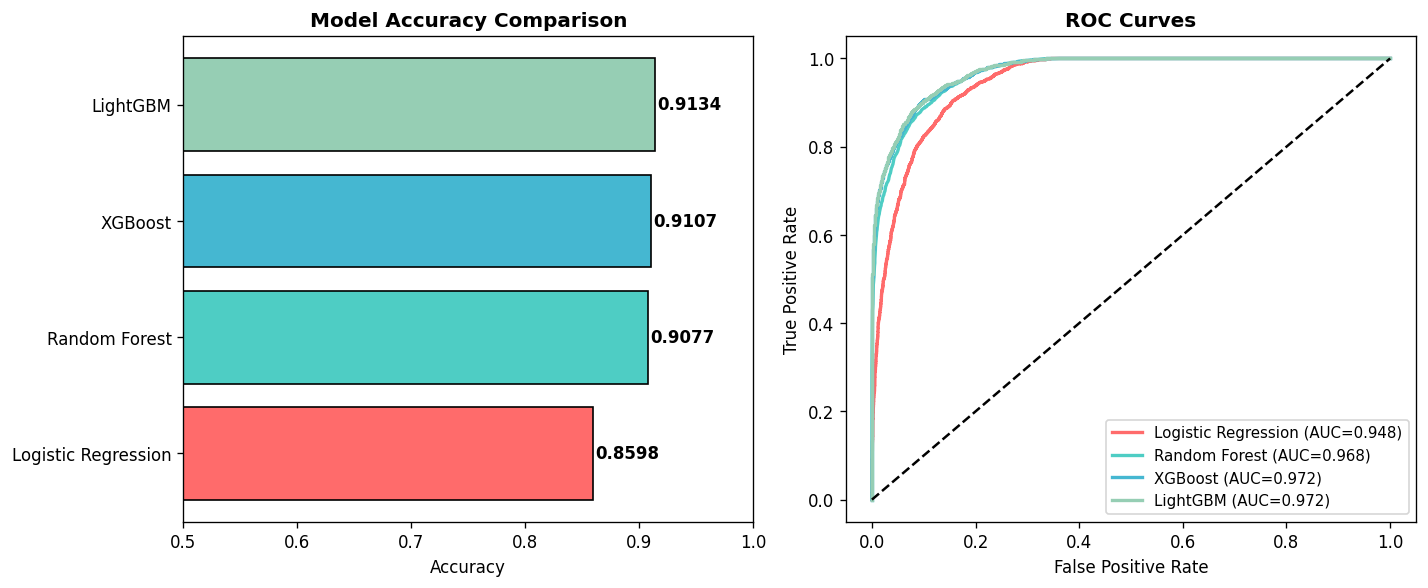

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names = list(results.keys())
accs  = [results[n]['acc'] for n in names]
bar_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

axes[0].barh(names, accs, color=bar_colors, edgecolor='black')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(accs):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')

for n, col in zip(names, bar_colors):
    fpr, tpr, _ = roc_curve(y_test, results[n]['prob'])
    axes[1].plot(fpr, tpr, label=f"{n} (AUC={results[n]['auc']:.3f})", color=col, lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 9. 🏆 Best Model – LightGBM Deep Dive

**LightGBM** wins: **91.34% Accuracy | AUC = 0.9724**

**Reading the confusion matrix:**
- **True Negatives (top-left)**: Correctly predicted "Not Default"
- **True Positives (bottom-right)**: Correctly predicted "Default"
- **False Negatives (bottom-left)**: Missed defaulters ← most costly in banking!


LightGBM – Classification Report
              precision    recall  f1-score   support

    Approved       0.96      0.92      0.94      7000
   Defaulted       0.77      0.88      0.82      2000

    accuracy                           0.91      9000
   macro avg       0.87      0.90      0.88      9000
weighted avg       0.92      0.91      0.92      9000


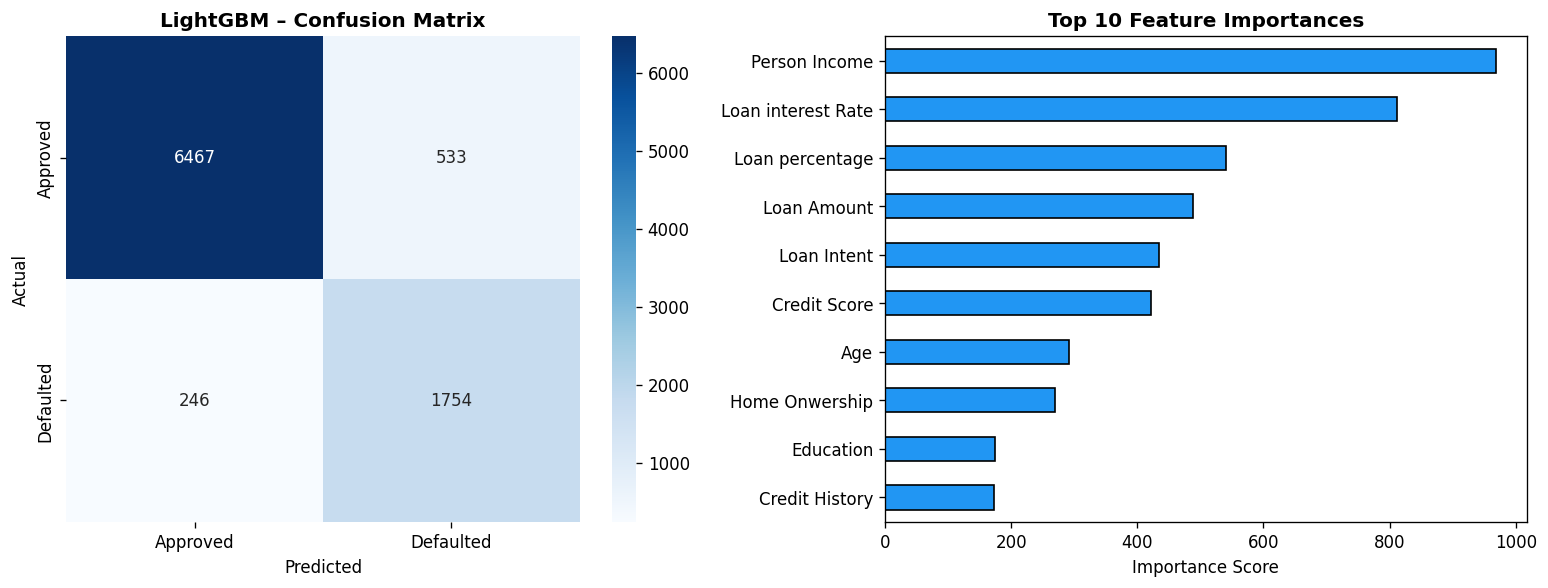

In [ ]:
print("LightGBM – Classification Report")
print("=" * 55)
print(classification_report(y_test, results['LightGBM']['pred'],
                             target_names=['Approved', 'Defaulted']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, results['LightGBM']['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Approved', 'Defaulted'],
            yticklabels=['Approved', 'Defaulted'])
axes[0].set_title('LightGBM – Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature Importance
fi = pd.Series(results['LightGBM']['model'].feature_importances_, index=X.columns)
fi.sort_values(ascending=True).tail(10).plot(kind='barh', ax=axes[1],
    color='#2196F3', edgecolor='black')
axes[1].set_title('Top 10 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## 10. ✅ Conclusion

### 📊 Final Results

| Model | Accuracy | AUC-ROC |
|-------|----------|---------|
| Logistic Regression | 85.98% | 0.9476 |
| Random Forest | 90.77% | 0.9678 |
| XGBoost | 91.07% | 0.9718 |
| **LightGBM** ⭐ | **91.34%** | **0.9724** |

### 🔑 Key Findings

1. **LightGBM is the best model** — 91.34% accuracy and AUC of 0.9724.
2. **Most important predictors** of loan default: Credit Score, Loan-to-Income Percentage, Interest Rate, and Person Income.
3. **SMOTE was crucial** — balancing the 78/22 imbalance prevented the model from being biased toward "Approved."
4. All boosting models (XGBoost, LightGBM) significantly outperformed the linear baseline.

### 💡 Beginner Takeaways

- Always **explore your data** (EDA) before modeling — it reveals what matters
- Always **handle class imbalance** — it's extremely common in real-world datasets
- Compare **multiple models** and use **AUC-ROC** (not just accuracy) for imbalanced targets
- **Feature importance** tells you *why* the model makes its decisions

---
*Dataset: 45,000 loan records | Best Model: LightGBM | AUC = 0.9724*
